# SVM Exercises

In [128]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [129]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

dataset = pd.read_csv(url, names=names)

Split data into training, colidation, and test sets with a test size of 25%

In [130]:
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

X_train, X_test, y_train, y_test = train_test_split(dataset[X_cols], dataset[y_col], test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)

Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [131]:
# YOUR CODE HERE

model = SVC(gamma=1.0, random_state=0)
model.fit(X_train, y_train)

SVC(gamma=1.0, random_state=0)

Print accuracy of training and validation data

In [132]:
# YOUR CODE HERE
y_train_pred = model.predict(X_train)
print(f"Training accuracy: {metrics.accuracy_score(y_train, y_train_pred)}")

y_val_pred = model.predict(X_val)
print(f"Validation accuracy: {metrics.accuracy_score(y_val, y_val_pred)}")

Training accuracy: 1.0
Validation accuracy: 0.6666666666666666


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [133]:
# YOUR CODE HERE

model_low = SVC(gamma=0.001, random_state=0)
model_low.fit(X_train, y_train)

SVC(gamma=0.001, random_state=0)

Print accuracy of training and validation data

In [134]:
# YOUR CODE HERE
y_train_pred_low = model_low.predict(X_train)
print(f"Training accuracy: {metrics.accuracy_score(y_train, y_train_pred_low)}")

y_val_pred_low = model_low.predict(X_val)
print(f"Validation accuracy: {metrics.accuracy_score(y_val, y_val_pred_low)}")

Training accuracy: 0.845213849287169
Validation accuracy: 0.7398373983739838


Explain the accuracy results below. 

The high gamma model had a much higher (perfect) training accuracy, but a lower validation accuracy, which is a very strong sign it is overfitting the training data. The lower gamma model had a lower but still strong training accuracy of around 86%, but the validation accuracy was higher, and closer to the training accuracy. For the low gamma model, it is still likely overfitting because validation accuracy is significantly lower than training accuracy.

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

[[82  0]
 [41  0]]
[[74  8]
 [24 17]]


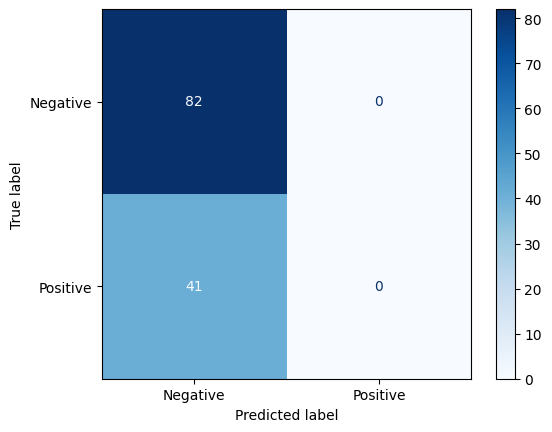

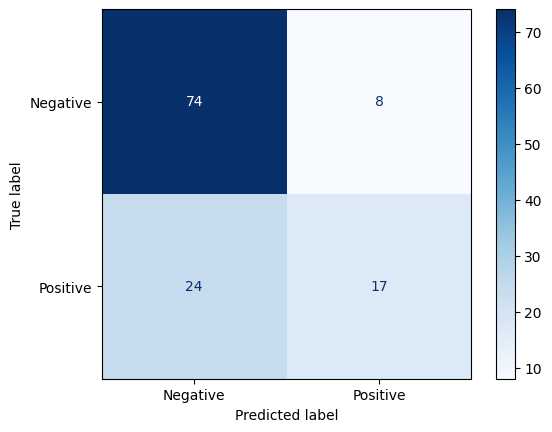

In [135]:
# YOUR CODE HERE
from sklearn.metrics import ConfusionMatrixDisplay

print(metrics.confusion_matrix(y_val, y_val_pred))

ConfusionMatrixDisplay.from_predictions(
    y_true=y_val,
    y_pred=y_val_pred,
    display_labels=["Negative", "Positive"],
    cmap=plt.cm.Blues
)

print(metrics.confusion_matrix(y_val, y_val_pred_low))

ConfusionMatrixDisplay.from_predictions(
    y_true=y_val,
    y_pred=y_val_pred_low,
    display_labels=["Negative", "Positive"],
    cmap=plt.cm.Blues
)